# **🛩️ ATAS**

The **ATAS** (Airial Threat Assesment System) is an end-to-end machine learning engineering project that combines
- computer vision,
- structured machine learning,
- tactical scenario generation,
- and interactive visualization into a single pipeline.

**The project is divided into three major components:**
- Aircraft Classification Model
- ETA Regressor Model
- Hit Classification Model
---

#### **In this notebook**

# **Aircraft Classification Model**

This notebook focuses on building the **Aircraft Classification Model** using `TensorFlow` and `transfer learning techniques` to classify military aircraft into  `101` different categories.

## **1. Problem Definition**

Given an image of a military aircraft, can a deep learning computer vision model (multi-class classification neural network) correctly classify the aircraft into its respective category?

---

## **2. Dataset**

The dataset used in this project contains military aircraft images across 101 aircraft categories and is being taken from [Military Aircraft Detection Dataset on Kaggle](https://www.kaggle.com/datasets/a2015003713/militaryaircraftdetectiondataset/data).

The dataset includes:
- fighter jets,
- bombers,
- helicopters,
- transport aircraft,
- UAVs,
- and reconnaissance aircraft.

Images contain variations in:
- aircraft angles,
- lighting conditions,
- backgrounds,
- scales,
- and image quality.

For this notebook, the `crop/` portion of the dataset will be used since it already contains aircraft images organized by class labels, making it suitable for multi-class image classification tasks.

The dataset was originally designed for fine-grained military aircraft recognition, where some visually similar aircraft variants are grouped into the same class due to minimal external differences.

<details>
<summary>View all 101 aircraft classes</summary>

`A10, A400M, AG600, AH64, AKINCI, AV8B, An124, An22, An225, An72, B1, B2, B21, B52, Be200, C1, C130, C17, C2, C390, C5, CH47, CH53, CL415, E2, E7, EF2000, EMB314, F117, F14, F15, F16, F18, F2, F22, F35, F4, FCK1, H6, Il76, J10, J20, J35, J36, J50, JAS39, JF17, JH7, KAAN, KC135, KF21, KIZILELMA, KJ600, Ka27, Ka52, MQ20, MQ25, MQ28, MQ9, Mi24, Mi26, Mi28, Mi8, Mig29, Mig31, Mirage2000, NH90, P3, RQ4, Rafale, SR71, Su24, Su25, Su34, Su47, Su57, T50, TB001, TB2, Tejas, Tornado, Tu160, Tu22M, Tu95, U2, UH60, US2, V22, V280, Vulcan, WZ10, WZ7, WZ9, X29, X32, XB70, XQ58, Y20, YF23, Z10, Z19`

</details>

---

## **3. Evaluation**

The goal is to correctly classify a military aircraft image into one of 101 categories.

The model will be considered performing well if it achieves **above 80% classification accuracy** on the validation set.

Additional indicators we will track:
- training & validation loss curves (to detect overfitting),
- confusion matrix (to see which aircraft classes the model confuses with each other),
- per-class prediction confidence,
- and visual inspection of sample predictions.

---

## **4. Features**

Some information about the data:

* We are dealing with images (unstructured data) so we will be using deep learning / transfer learning.
* There are `101` categories of military aircraft (101 different classes).
* The `crop/` folder contains `41,441` total cropped aircraft images organized by class label.
* Each class has its own subfolder inside `crop/` — the folder name is the label.
* The `labels_with_split.csv` file contains bounding box annotations and a predefined split column:
  - ~31k training annotations
  - ~7.5k validation annotations
  - ~2.7k test annotations

* Note: This CSV was designed for object detection. For our classifier we use the `crop/` folder directly, but will use the `split` column to respect the original train/validation/test separation.
* Images vary in angle, lighting, background, and scale — making this a fine-grained classification problem.
* Some visually similar aircraft variants are grouped into the same class due to minimal external differences.

## **5. Preparing the Tools**

We will be using the following libraries for this project:
- **NumPy** — numerical operations
- **Pandas** — data manipulation and loading labels
- **Matplotlib** — visualizing images and training curves
- **TensorFlow / Keras** — building and training the deep learning model
- **Scikit-learn** — creating train/validation/test splits and evaluation metrics
- **OS / Pathlib** — navigating file paths and loading images from disk

In [1]:
# Importing the required tools

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras

print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)
print("Pandas Version:", pd.__version__)
print("Keras Version:", keras.__version__)

# Able to see all the columns
pd.set_option('display.max_columns', None)

2026-05-09 18:12:11.772560: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-09 18:12:25.219928: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


TensorFlow Version: 2.16.1
NumPy Version: 1.26.4
Pandas Version: 3.0.2
Keras Version: 3.14.0


## **6. Load Images**

We will load images from the `crop/` folder of the dataset.
Each subfolder inside `crop/` represents one aircraft class and contains cropped images of that aircraft.

Steps:
1. Define the path to the `crop/` folder ✅
2. Count total images and classes ✅
3. Load image file paths and their corresponding class labels ✅
4. Verify the data loaded correctly ✅

### **Environment & Path Configuration**

This section configures project paths and automatically detects whether the notebook is running **locally** or in **Google Colab**.

In [2]:
import glob
from pathlib import Path
import os

# Set to "auto" (recommended), "colab", or "local"
FORCE_ENV = "auto"

def detect_env():
    in_colab = "COLAB_GPU" in os.environ or os.path.exists("/content")
    return "colab" if in_colab else "local"

ENV = detect_env() if FORCE_ENV == "auto" else FORCE_ENV

if ENV == "colab":
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/ATAS_Project")
    DATA_ROOT = PROJECT_ROOT / "data"
    LOG_DIR = PROJECT_ROOT / "logs"
else:
    PROJECT_ROOT = Path("..")
    DATA_ROOT = PROJECT_ROOT / "data"
    LOG_DIR = PROJECT_ROOT / "logs"

CROP_DIR = DATA_ROOT / "crop"

print("ENV:", ENV)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("CROP_DIR:", CROP_DIR)
print("LOG_DIR:", LOG_DIR)
print("CROP_DIR exists:", CROP_DIR.exists())
print("Classes found:", len(glob.glob(str(CROP_DIR / "*"))))

ENV: local
PROJECT_ROOT: ..
DATA_ROOT: ../data
CROP_DIR: ../data/crop
LOG_DIR: ../logs
CROP_DIR exists: True
Classes found: 101


In [3]:
import os
from pathlib import Path

CROP_DIR = DATA_ROOT / "crop"

class_folders = sorted(os.listdir(CROP_DIR))
total_images = sum(len(os.listdir(CROP_DIR / cls)) for cls in class_folders)

print(f"Total classes: {len(class_folders)}")
print(f"Total images: {total_images}")

Total classes: 101
Total images: 41441


In [4]:
# Checking out labels csv

labels_with_split = pd.read_csv("../data/labels_with_split.csv")
print(labels_with_split.shape)
print(labels_with_split.head())

(41441, 9)
                           filename  width  height class  xmin  ymin  xmax  \
0  0000e97ea2d086d6759b19b288a8a72c   4928    3264  Mi28  1380  1904  1522   
1  0000e97ea2d086d6759b19b288a8a72c   4928    3264  Mi28  1809  1625  1958   
2  0000e97ea2d086d6759b19b288a8a72c   4928    3264  Mi28  2400  1571  2532   
3  0000e97ea2d086d6759b19b288a8a72c   4928    3264  Mi28  3935  1772  4100   
4  00010041af654d0b8e1e16c824fa9867   1360    2048  UH60   835   526  1233   

   ymax  split  
0  2014  train  
1  1759  train  
2  1727  train  
3  1891  train  
4   741  train  


In [5]:
labels_with_split

,filename,width,height,class,xmin,ymin,xmax,ymax,split
0,0000e97ea2d086d6759b19b288a8a72c,4928,3264,Mi28,1380,1904,1522,2014,train
1,0000e97ea2d086d6759b19b288a8a72c,4928,3264,Mi28,1809,1625,1958,1759,train
2,0000e97ea2d086d6759b19b288a8a72c,4928,3264,Mi28,2400,1571,2532,1727,train
3,0000e97ea2d086d6759b19b288a8a72c,4928,3264,Mi28,3935,1772,4100,1891,train
4,00010041af654d0b8e1e16c824fa9867,1360,2048,UH60,835,526,1233,741,train
...,...,...,...,...,...,...,...,...,...
41436,fff4d4af52e64d95bdafa29f77a81c97,817,479,Mi28,0,119,756,301,test
41437,fffb908c9824dc0da884c43cfe0312b8,6720,4480,EF2000,514,1302,6447,3206,test
41438,fffb908c9824dc0da884c43cfe0312b8,6720,4480,EF2000,0,1746,2698,3061,test
41439,fffd70f851b78035454c0a9367820ca3,1500,1000,B2,240,55,988,944,test


In [6]:
labels_with_split.describe()

,width,height,xmin,ymin,xmax,ymax
count,41441.000000,41441.000000,41441.000000,41441.000000,41441.000000,41441.000000
mean,2056.475133,1399.343307,715.019087,507.202191,1325.372144,805.921817
std,1276.872710,830.675656,798.662180,465.634793,953.931200,573.969376
min,112.000000,119.000000,0.000000,0.000000,22.000000,9.000000
25%,1080.000000,768.000000,142.000000,185.000000,668.000000,411.000000
50%,1600.000000,1170.000000,449.000000,366.000000,1041.000000,639.000000
75%,2830.000000,1879.000000,981.000000,685.000000,1712.000000,1034.000000
max,8508.000000,7360.000000,7895.000000,4919.000000,8256.000000,6720.000000


In [7]:
# Checking wheather there any null values
labels_with_split.info()

<class 'pandas.DataFrame'>
RangeIndex: 41441 entries, 0 to 41440
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   filename  41441 non-null  str  
 1   width     41441 non-null  int64
 2   height    41441 non-null  int64
 3   class     41441 non-null  str  
 4   xmin      41441 non-null  int64
 5   ymin      41441 non-null  int64
 6   xmax      41441 non-null  int64
 7   ymax      41441 non-null  int64
 8   split     41441 non-null  str  
dtypes: int64(6), str(3)
memory usage: 2.8 MB


**From info given above:**
- `filename`, `class`, `split` --> are of `str` datatype
- `width`, `height`, `xmin`, `ymin`, `xmax`, `ymax` --> are of `int` data types 

In [8]:
# Counting number of classes in the labels file
labels_with_split["class"].value_counts()

class
F16     2061
F18     1796
C130    1590
F35     1569
F15     1564
        ... 
J50       46
V280      39
WZ10      32
WZ9       15
MQ20      11
Name: count, Length: 101, dtype: int64

**Class distribution is very unbalanced:**

Example:
- **F16** has `2,061` crops
- **MQ20** has only `11`

That's a big gap. Some aircraft are rare in the dataset, some are very common. This will matter later when we train, but we'll handle it when we get there.

In [9]:
# Checking the split division of the dataset
labels_with_split["split"].value_counts()

split
train         31127
validation     7545
test           2769
Name: count, dtype: int64

**We use the CSV to build full file paths for each image.
Each row will have: filepath, label, and split.**

In [10]:
# Peek inside one class folder to see how filenames are structred

sample_class = os.listdir(CROP_DIR)[0]
print("Class: ", sample_class)

sample_files = os.listdir(CROP_DIR/ sample_class)[:5]
print("Files: ", sample_files)

Class:  A10
Files:  ['00c09f406d31a0cd9402862fbd26d930_0.jpg', '00d4b7ea93ca1417393007c61c519f88_0.jpg', '01169f9ba735dfcb46dab62bc5649de9_0.jpg', '016fd73cdece1b76562ec526ba9390ff_0.jpg', '01ed4d81c5d733cbaa266b6ea7821254_0.jpg']


**It confirmed two things:**

- The class folder name **(A10)** is the label
- The files inside are the cropped images we'll use

That's it. That's all we needed to see.

---

### **Building the File Path Dataframe**
Scan all class folders in `crop/` and build a clean dataframe with filepath and label columns.

**We write code that does this:**

- Go through every class folder in crop/
- For every image inside, record the full path and the folder name as the label
- End up with a clean dataframe of filepath + label

In [11]:
# Data Collection
# Scan all the folders and build filepath + label list

records = []

for class_folder in CROP_DIR.iterdir():
    if class_folder.is_dir():
        for image_path in class_folder.glob("*.jpg"):
            records.append({
                "filepath" : str(image_path),
                "label" : class_folder.name
            })            
# records

In [12]:
# Convert to a dataframe
image_df = pd.DataFrame(records)
print(image_df.shape)
print(image_df.head())

(41441, 2)
                                            filepath label
0  ../data/crop/A10/00c09f406d31a0cd9402862fbd26d...   A10
1  ../data/crop/A10/00d4b7ea93ca1417393007c61c519...   A10
2  ../data/crop/A10/01169f9ba735dfcb46dab62bc5649...   A10
3  ../data/crop/A10/016fd73cdece1b76562ec526ba939...   A10
4  ../data/crop/A10/01ed4d81c5d733cbaa266b6ea7821...   A10


In [13]:
image_df.head()

,filepath,label
0,../data/crop/A10/00c09f406d31a0cd9402862fbd26d...,A10
1,../data/crop/A10/00d4b7ea93ca1417393007c61c519...,A10
2,../data/crop/A10/01169f9ba735dfcb46dab62bc5649...,A10
3,../data/crop/A10/016fd73cdece1b76562ec526ba939...,A10
4,../data/crop/A10/01ed4d81c5d733cbaa266b6ea7821...,A10


In [14]:
labels_with_split.shape, image_df.shape

# Both having same number of rows

((41441, 9), (41441, 2))

#### **Merging: Add Split Information**

#### **What We Have So Far**

Our `image_df` dataframe:
- **41,441 rows** ✅ (matches the CSV exactly)
- **2 columns:** `filepath`, `label`
- Labels extracted from folder names ✅

#### **What We Need**

Add the `split` column from `label_with_split.csv` so we know which images are for:
- **Training** (75%)
- **Validation** (18%)
- **Testing** (7%)

#### **The Challenge: Joining Two Tables**

Both dataframes have the same 41,441 images, but they identify them differently:

| Source | File ID Format | Example |
|--------|----------------|---------|
| `image_df` | Full filepath | `../data/crop/A10/00c09f406d31a0cd9_0.jpg` |
| `label_with_split` | Filename only | `00c09f406d31a0cd9` |

**We need to extract the filename from the filepath and use it as the merge key.**

In [15]:
# Get first filename from CSV for Mi28
mi28_csv = labels_with_split[labels_with_split["class"] == "Mi28"]["filename"].iloc[0]
print("CSV filename for Mi28: ", mi28_csv)

# Get the first file from Mi28 crop folder
mi28_crop = os.listdir(CROP_DIR/ "Mi28")[:5]
print("Crop filename: ", mi28_crop)

CSV filename for Mi28:  0000e97ea2d086d6759b19b288a8a72c
Crop filename:  ['0000e97ea2d086d6759b19b288a8a72c_0.jpg', '0000e97ea2d086d6759b19b288a8a72c_1.jpg', '0000e97ea2d086d6759b19b288a8a72c_2.jpg', '0000e97ea2d086d6759b19b288a8a72c_3.jpg', '04dbc4ca7d87fb38b22b415bc7c280c0_0.jpg']


### **Adding Split Column to image_df**

We need to match each image filepath to its train/val/test split from the CSV.

The crop filenames look like: `0000e97e_0.jpg`  
The CSV filenames look like: `0000e97e`

They share the same base name. So we:
1. Extract the base filename from the filepath (strip `_0.jpg`) ✅
2. Match it with the CSV filename to get the split ✅
3. Add split to image_df ✅
4. Drop the temporary matching column ✅

In [16]:
# How it works
x = "../data/crop/A10/00c09f_0.jpg"

path = Path(x)
print(path)

stems = path.stem
print(stems)

split = stems.rsplit("_", 1) # It splits a string from the right side at the last(only 1) underscore only.
print(split)

result = split[0]
print(result)

../data/crop/A10/00c09f_0.jpg
00c09f_0
['00c09f', '0']
00c09f


In [17]:
# 1.) Extract base filenames temporarily for matching
image_df["temp"] = image_df["filepath"].apply(
    lambda x : Path(x).stem.rsplit("_", 1)[0]  # Stem -> Gives the filename without the folder and without the extension.
)

image_df.head()

,filepath,label,temp
0,../data/crop/A10/00c09f406d31a0cd9402862fbd26d...,A10,00c09f406d31a0cd9402862fbd26d930
1,../data/crop/A10/00d4b7ea93ca1417393007c61c519...,A10,00d4b7ea93ca1417393007c61c519f88
2,../data/crop/A10/01169f9ba735dfcb46dab62bc5649...,A10,01169f9ba735dfcb46dab62bc5649de9
3,../data/crop/A10/016fd73cdece1b76562ec526ba939...,A10,016fd73cdece1b76562ec526ba9390ff
4,../data/crop/A10/01ed4d81c5d733cbaa266b6ea7821...,A10,01ed4d81c5d733cbaa266b6ea7821254


In [18]:
# 2.) Get all the unique file names from labels_with_split along with split tag
split_map = labels_with_split[["filename", "split"]].drop_duplicates() # Drops the dublicate rows
print(split_map.shape)
print(split_map.head())

(23143, 2)
                            filename  split
0   0000e97ea2d086d6759b19b288a8a72c  train
4   00010041af654d0b8e1e16c824fa9867  train
5   000106393cfe2343888c584e65fd2274  train
6   0002f2cc10d90392efc3ad30cbda6490  train
22  00032844ab679240fc03ecd27d29a6aa  train


**Note:** Notice the shape --> 23,143 rows. Down from 41,441.

That's because duplicates are gone. Each original photo now appears only once, with its split. Clean.

**Two columns:**

- filename — the original photo name
- split — train, val, or test

That's our lookup table. Given any filename, we can find its split.

In [19]:
print(image_df.columns.tolist())

['filepath', 'label', 'temp']


In [20]:
image_df.head()

,filepath,label,temp
0,../data/crop/A10/00c09f406d31a0cd9402862fbd26d...,A10,00c09f406d31a0cd9402862fbd26d930
1,../data/crop/A10/00d4b7ea93ca1417393007c61c519...,A10,00d4b7ea93ca1417393007c61c519f88
2,../data/crop/A10/01169f9ba735dfcb46dab62bc5649...,A10,01169f9ba735dfcb46dab62bc5649de9
3,../data/crop/A10/016fd73cdece1b76562ec526ba939...,A10,016fd73cdece1b76562ec526ba9390ff
4,../data/crop/A10/01ed4d81c5d733cbaa266b6ea7821...,A10,01ed4d81c5d733cbaa266b6ea7821254


In [21]:
len(image_df), len(split_map)

(41441, 23143)

In [22]:
# 3.) Merge Split Information into image_df
image_df = image_df.merge(split_map, left_on="temp", right_on="filename")
image_df.head()

,filepath,label,temp,filename,split
0,../data/crop/A10/00c09f406d31a0cd9402862fbd26d...,A10,00c09f406d31a0cd9402862fbd26d930,00c09f406d31a0cd9402862fbd26d930,train
1,../data/crop/A10/00d4b7ea93ca1417393007c61c519...,A10,00d4b7ea93ca1417393007c61c519f88,00d4b7ea93ca1417393007c61c519f88,train
2,../data/crop/A10/01169f9ba735dfcb46dab62bc5649...,A10,01169f9ba735dfcb46dab62bc5649de9,01169f9ba735dfcb46dab62bc5649de9,train
3,../data/crop/A10/016fd73cdece1b76562ec526ba939...,A10,016fd73cdece1b76562ec526ba9390ff,016fd73cdece1b76562ec526ba9390ff,train
4,../data/crop/A10/01ed4d81c5d733cbaa266b6ea7821...,A10,01ed4d81c5d733cbaa266b6ea7821254,01ed4d81c5d733cbaa266b6ea7821254,train


### **What happened and why?**

**Why we needed this:**
`image_df` had filepath and label but no split (train/val/test).
The split info was sitting in `labels_with_split` CSV.

**The problem:**
- `image_df` filenames look like: `00c09f406d_0.jpg`
- CSV filenames look like: `00c09f406d`
- They don't look the same so we can't match directly.

**What we did:**

1. Extracted the base filename from filepath into a temporary `temp` column
2. Created `split_map` -> a clean lookup table with just filename and split using `label_with_split`
3. Merged both dataframes by matching `temp` with `filename`

**How merge works:**

It doesn't match by row number, it matches by value.
Like a dictionary lookup, give it a word, it finds the meaning.
Length of both dataframes doesn't matter. **(41441, 23143)** -> (`image_df`, `split_map`)

**Result:**
Each image now has its correct filepath, label, and split.

In [23]:
# 4.) Drop temp and filename columns that are no longer needed
image_df = image_df.drop(columns=["temp", "filename"])

print(image_df.shape)
image_df

(41441, 3)


,filepath,label,split
0,../data/crop/A10/00c09f406d31a0cd9402862fbd26d...,A10,train
1,../data/crop/A10/00d4b7ea93ca1417393007c61c519...,A10,train
2,../data/crop/A10/01169f9ba735dfcb46dab62bc5649...,A10,train
3,../data/crop/A10/016fd73cdece1b76562ec526ba939...,A10,train
4,../data/crop/A10/01ed4d81c5d733cbaa266b6ea7821...,A10,train
...,...,...,...
41436,../data/crop/Z19/ffb195452d886cd8cd303777eee8a...,Z19,test
41437,../data/crop/Z19/ffb195452d886cd8cd303777eee8a...,Z19,test
41438,../data/crop/Z19/ffb195452d886cd8cd303777eee8a...,Z19,test
41439,../data/crop/Z19/ffb195452d886cd8cd303777eee8a...,Z19,test


In [24]:
# Save image_df to CSV for future use
output_path = DATA_ROOT / "image_with_labels.csv"
image_df.to_csv(output_path, index=False)

print("Saved to: ", output_path)
print("Shape: ", image_df.shape)

Saved to:  ../data/image_with_labels.csv
Shape:  (41441, 3)


### **How image_df Was Built**

![image_df_build_flowchat](../assets/notes/image_df_build_flowchart.png)

**Left side (teal):** Scanned the `crop/` folder directly.
Folder name = label. Got filepath + label for all 41,441 images.

**Right side (purple):** Used `labels_with_split.csv` only for the split column.
Dropped duplicates → 23,143 unique original photos.
Extracted base filename from filepath (stripped `_0.jpg`) into a temp column.

**Merge (amber):** Matched temp column with CSV filename → brought split across.

**Result (green):** Clean dataframe with filepath, label, split.
No bounding boxes. No duplicates. Ready for training.

---

## **7. Exploratory Data Analysis (EDA)**

Before building a model, we need to *see* the data.

Goals for this section:
- Confirm the CSV loaded correctly ✅
- Check class distribution (are some aircraft overrepresented?)
- Visualize sample images from different classes

In [26]:
# Reloading the refined csv
aircraft_labels = pd.read_csv("../data/image_with_labels.csv")
print(aircraft_labels.shape)
aircraft_labels

(41441, 3)


,filepath,label,split
0,../data/crop/A10/00c09f406d31a0cd9402862fbd26d...,A10,train
1,../data/crop/A10/00d4b7ea93ca1417393007c61c519...,A10,train
2,../data/crop/A10/01169f9ba735dfcb46dab62bc5649...,A10,train
3,../data/crop/A10/016fd73cdece1b76562ec526ba939...,A10,train
4,../data/crop/A10/01ed4d81c5d733cbaa266b6ea7821...,A10,train
...,...,...,...
41436,../data/crop/Z19/ffb195452d886cd8cd303777eee8a...,Z19,test
41437,../data/crop/Z19/ffb195452d886cd8cd303777eee8a...,Z19,test
41438,../data/crop/Z19/ffb195452d886cd8cd303777eee8a...,Z19,test
41439,../data/crop/Z19/ffb195452d886cd8cd303777eee8a...,Z19,test


In [ ]:
# Check class distribution because imbalance can bias the model toward majority classes
df = pd.DataFrame(aircraft_labels["label"].value_counts())
df.T

label,F16,F18,C130,F35,F15,J20,V22,EF2000,C2,J10,Rafale,A10,C17,F4,F22,US2,B1,B52,JAS39,B2,AH64,F14,A400M,Su34,Su24,P3,Mig31,Tornado,Tu22M,E2,H6,Su57,Mirage2000,Tu95,AV8B,Su25,KC135,Tu160,TB2,Vulcan,CL415,C5,Mig29,CH47,F117,Y20,MQ9,Mi24,UH60,U2,Mi8,RQ4,Be200,EMB314,Il76,JH7,AG600,JF17,SR71,Ka52,C1,E7,An124,T50,Mi28,C390,An72,XB70,F2,Tejas,Ka27,WZ7,J35,AKINCI,YF23,Z10,FCK1,Mi26,Z19,KF21,Su47,An22,CH53,An225,KJ600,TB001,J36,X32,KAAN,NH90,X29,XQ58,KIZILELMA,B21,MQ25,MQ28,J50,V280,WZ10,WZ9,MQ20
count,2061,1796,1590,1569,1564,917,916,842,833,824,821,793,749,729,713,667,663,639,626,576,566,554,544,538,534,519,504,493,481,480,479,478,469,466,464,458,453,447,431,415,408,403,402,381,378,373,372,371,370,330,325,310,303,302,299,299,281,274,272,271,254,227,226,223,220,206,199,177,168,165,163,158,156,150,147,146,133,133,131,125,124,117,113,112,107,105,102,97,87,73,69,66,64,63,60,47,46,39,32,15,11


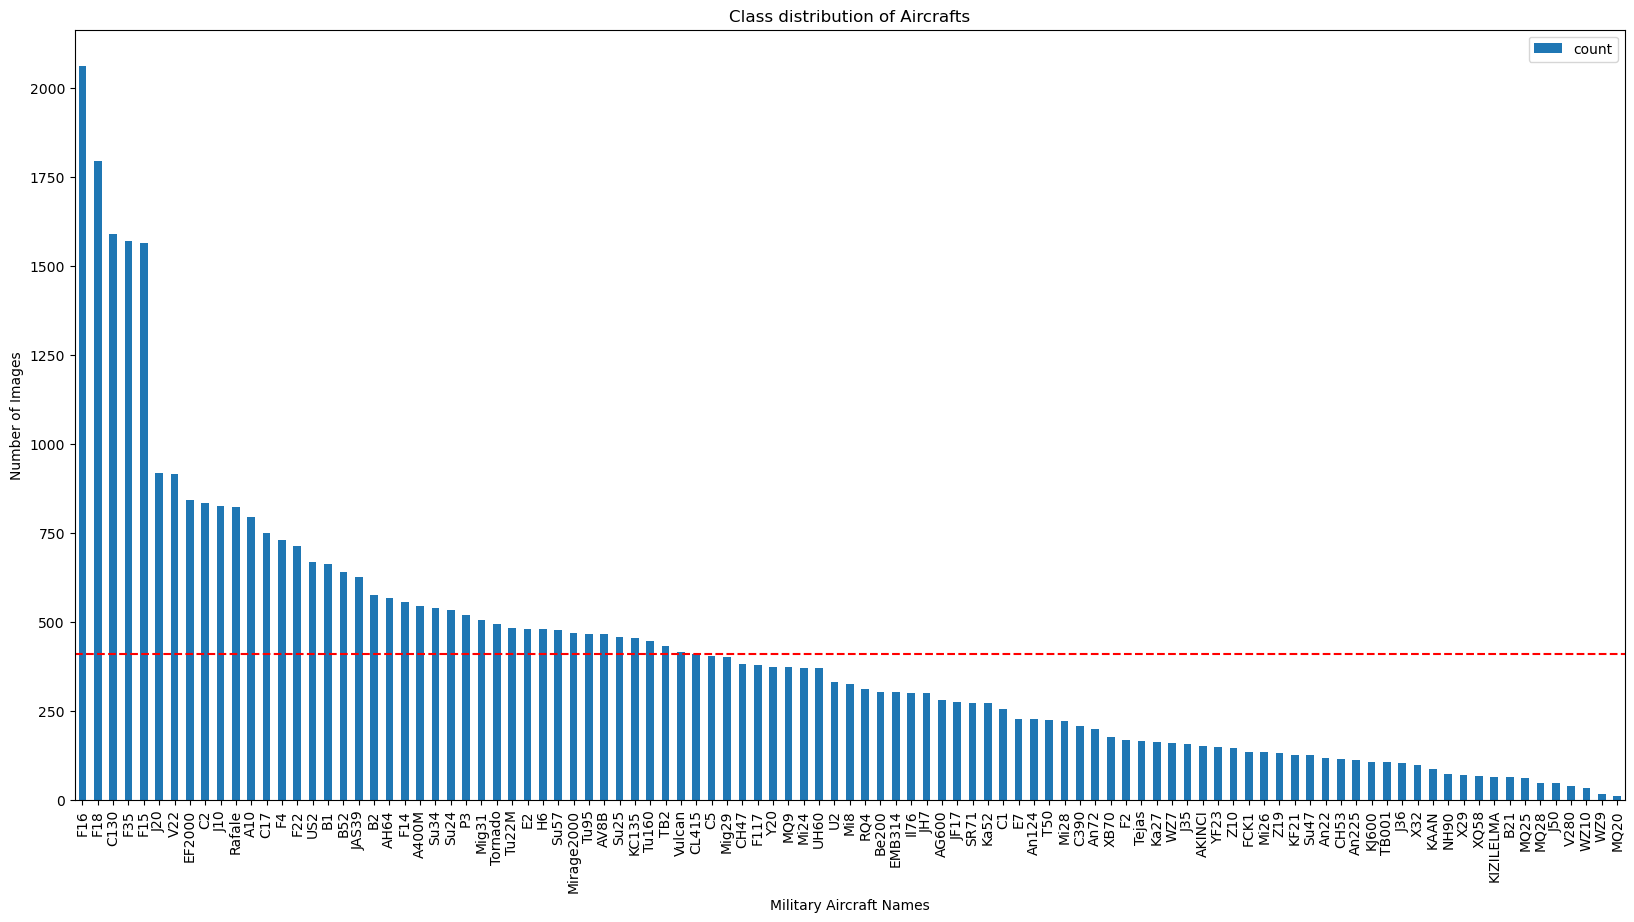

In [ ]:
# Visualization of Category distribution of Aircrafts

df.plot.bar(figsize=(20, 10))
plt.title("Class distribution of Aircrafts")
plt.xlabel("Military Aircraft Names")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)
plt.axhline(y=np.mean(df.values),
           linestyle="--",
           color="red")
plt.show();